# Raumakustik: Analyse und Design, SoSe 2026
## Hausaufgabe I

## Hinweise

Abzugeben ist eine Jupyter Notebook Datei mit Text und Python Code einschließlich daraus erzeugten Abbildungen. Achten Sie darauf, dass alle formalen Anforderungen eines wissenschaftlichen Textes (Literaturverweise, gut beschriftete Abbildungen etc.) erfüllt sind und dass der Code gut dokumentiert und ausführbar ist. 

Abgabetermin ist **Dienstag, 26. Mai 2026 (23:59 Uhr)**. Das Jupyter-Notebook ist gemäß der Namenskonvention *Gruppe_Gruppenbezeichnung_Hausaufgabe_001.ipynb* umzubenennen. Das zugehörige .zip-Archiv soll den Namen *Gruppe_Gruppenbezeichnung_Hausaufgabe_001.zip* tragen und alle zum Ausführen des Notebooks erforderlichen Dateien enthalten.

Der Upload erfolgt über ISIS und ist nur bis 23:59 Uhr möglich. Nach Ablauf dieser Frist wird das Upload-Fenster geschlossen und spätere Abgaben über ISIS können nicht mehr berücksichtigt werden.



In [77]:
# Zur Lösung der Hausaufgabe können folgende Module verwendet werden

import numpy as np
import scipy as sc 
import matplotlib.pyplot as plt
import pyfar as pf
import IPython.display as ipd

#### Gruppe 
**Name / Matrikelnummer**  
Person 1 /  
Person 2 /  
Person 3 /   
Person 4 /   

## Aufgabe 1 Oktavbandfilterung

a) Erzeugen Sie mit dem Modul **Scipy (kein pyfar!)** eine Bandpass-Filterbank für akustische Analysen in Oktavbändern mit Mittenfrequenzen von 125 Hz bis 8 kHz.

Verwenden Sie Butterworth-Filter 10. Ordnung und eine Filterstruktur mit einer Serie von Biquad-Filtern (second order sections) und einer Samplingrate von 44100 Hz.

Zeigen Sie exemplarisch, dass im Oktavband mit $f_m $= 1 kHz die Anforderungen der DIN EN 61260-1 für Oktavfilter der Klasse 1 erfüllt sind, indem Sie den Amplitudengang des Filters und die Toleranzgrenzen der DIN plotten. 

(3 Punkte)

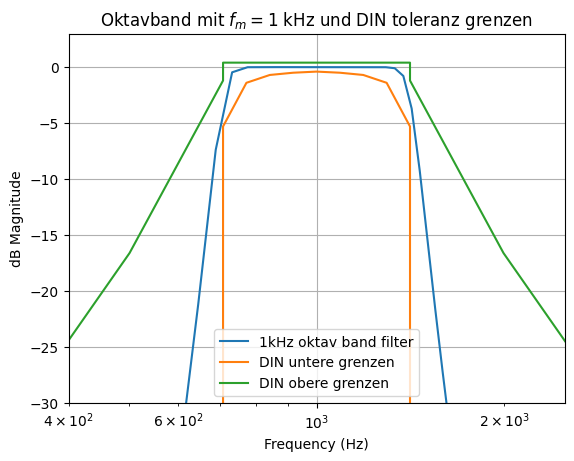

In [78]:
    # Loesung Aufgabe 1a
def butt_bandpass(lf, uf, fs):
    sos = sc.signal.butter(10, [lf, uf], btype='bandpass', fs=44100, output='sos')
    return sos

fs = 44100
fc =np.array([125,250,500,1000,2000,4000,8000])
butt_bank = []
plt.figure(1)
plt.clf()
for oktav in fc:
    sos = butt_bandpass(oktav /np.sqrt(2),oktav*np.sqrt(2),fs)
    butt_bank.append(sos)


G = 10**(3/10) 
exps= np.array([0,1/8,1/4,3/8,1/2,1/2,1,2,3,4])
uppertol = [0.4,0.5,0.7,1.4,5.3,1e5,1e5,1e5,1e5,1e5]
uppertol = -1 * np.append(np.flip(uppertol[1:]),uppertol)
lowertol = [-0.4,-0.4,-0.4,-0.4,-0.4,1.2,16.6,40.5,60,70]
lowertol = -1* np.append(np.flip(lowertol[1:]),lowertol)
x = -1* np.flip(exps[1:])
x = np.append(x,exps)
x = G**(x) * 1000
sos = butt_bank[3]
w ,h = sc.signal.sosfreqz(sos)
db = 20*np.log10(np.maximum(np.abs(h), 1e-5))
plt.semilogx( (fs * 0.5 / np.pi) *w, db, label="1kHz oktav band filter")
plt.semilogx( x, uppertol, label="DIN untere grenzen")
plt.semilogx( x, lowertol, label="DIN obere grenzen")

plt.xlabel('Frequency (Hz)')
plt.ylabel('dB Magnitude')
plt.title('Oktavband mit $f_m=1$ kHz und DIN toleranz grenzen')
plt.xlim(400,2500)
plt.ylim(-30,3)
plt.grid(True)
plt.legend(loc='best')
plt.show()





b) Erzeugen Sie eine Oktav-Filterbank in **Pyfar** und prüfen Sie ebenfalls die Anforderungen nach DIN 61260-1. 

(2 Punkte)

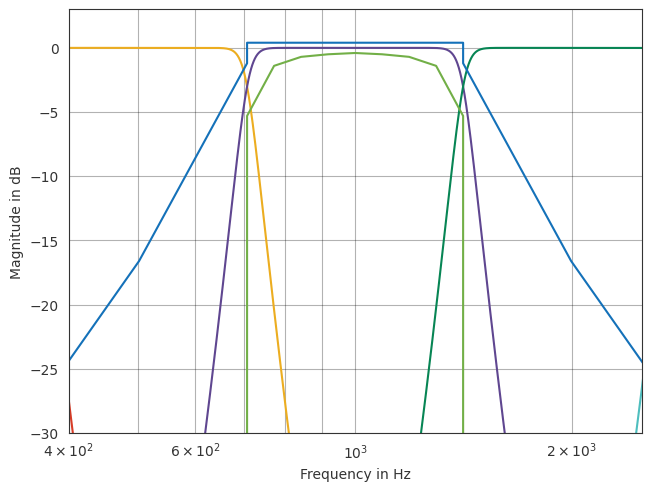

In [79]:
# Loesung Aufgabe 1b
# Loesung Aufgabe 1b
impulse = pf.signals.impulse(44100)
pfbank = pf.dsp.filter.fractional_octave_bands(signal=None, num_fractions=1, sampling_rate=44100 , frequency_range=(125, 8000), order=10)
pf.plot.freq(pfbank.process(impulse))
plt.semilogx( x, uppertol, label="DIN untere grenzen")
plt.semilogx( x, lowertol, label="DIN obere grenzen")
plt.xlim(400,2500)
plt.ylim(-30,3)
plt.show()

## Aufgabe 2

Die folgende Berechnung entspricht einer leicht vereinfachten Version des in

**Lundeby, A., Vigran, T. E., Bietz, H., & Vorländer, M. (1995). Uncertainties of measurements in room acoustics. Acta Acustica united with Acustica, 81(4), 344-355.**

beschriebenen Vorgehens. 

a. Laden Sie die im Teatro Olimpico (Vicenza) gemessene Impulsantwort mit pyfar ein. 

Bestimmen Sie den **Anfangspunkt** der Impulsantwort nach DIN 3382 und führen Sie eine entsprechende zeitliche Verschiebung durch. 

Kürzen Sie die Gesamtlänge der Impulsantwort auf 4.5 Sekunden mit einem zeitlichen Fenster. 

Berechnen Sie mit einer der oben erzeugten Filterbank die Oktavbandpass-gefilterten Impulsantworten und plotten diese als quadrierte und auf den Maximalwert als 0 dB-Punkt normierte und logarithmierte Kurven. 

**Die folgenden Berechnungsschritte sollen für jedes Oktavband durchgeführt werden.** 

(2 Punkte)

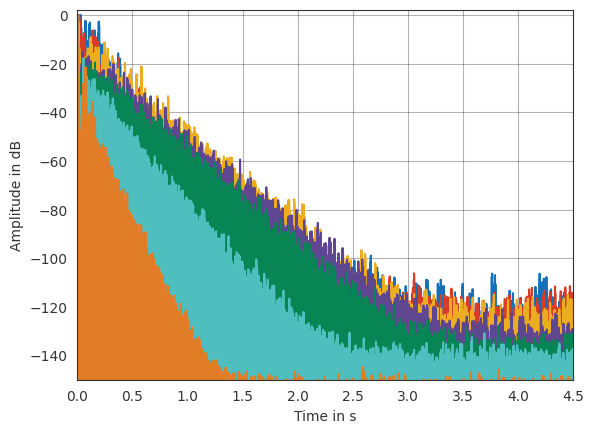

In [80]:
# Loesung Aufgabe 2a
rir = pf.io.read_audio('RIR_Vicenza.wav')
fs= 44100
# anfangspunkt 'wo sich das Signal erstmalig deutlich aus dem Störpegel abhebt, jedoch mindestens 20 dB unterhalb des Maximalwerts liegt.'
rirstart = pf.dsp.find_impulse_response_start(rir)[0]
es = 44100 * 4.5 + rirstart
wrir= pf.dsp.time_window(rir,[rirstart,es],window="boxcar",crop="window")
pfrir = pfbank.process(wrir)
sqir = pf.power((pfrir,2),domain="time")
sqir = pf.dsp.normalize(sqir, domain="time")
plt.figure(0)

pf.plot.time(sqir,dB=True)
plt.ylim(-150,2)

plt.show()


b. Berechnen Sie geglättete und wiederum normierte Versionen der quadrierten Impulsantwort als gleitenden Mittelwert mit einem Rechteckfenster von 50 ms Länge und Normierung auf das Maximum der geglätteten Kurve (0 dB-Punkt). 

Plotten Sie diese für die sieben Oktavbänder.

 (2 Punkte)

(-125.0, 2.0)

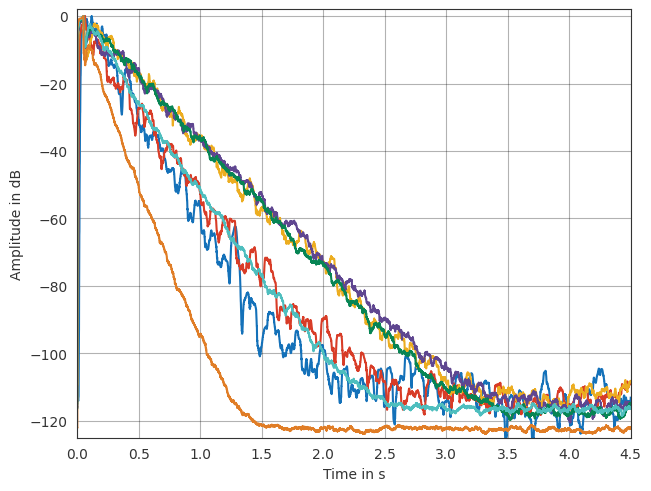

In [81]:
# Loesung Aufgabe 2b

fs = 44100
ln = int(fs * 50 * 10**(-3)) #50 ms in samples
window = pf.Signal(np.ones(ln)/ln,fs) #boxcar window
sqir = pf.dsp.convolve(sqir,window,mode='cyclic')
sqir = pf.dsp.normalize(sqir, domain='time')
pf.plot.time(sqir, dB=True)
plt.ylim(-125,2)

c. Bestimmen Sie den Anfangspunkt der Impulsantworten als das Maximum der geglätteten Kurve und das Ende der Impulsantwort als Schnittpunkt einer initialen Schätzung der Steigung der geglätteten Kurve mit dem Noise Floor. 

Die Steigung soll als lineare Regression zwischen dem Maximum der geglätteten Kurve und einem Punkt 10 dB oberhalb des Noise Floors berechnet werden. Der Noise Floor wird dabei als energetischer Mittelwert im Zeitintervall von **10 % bis 4,3 s** der Impulsantwort bestimmt.

Markieren Sie folgende Punkte in den Plots:

- Intervall zur Bestimmung des Noise Floor
- Anfangspunkt Impulsantwort 
- Noise Level
- Schnittpunkt der linearen Regression mit dem Noise Floor 
- Punkt 10 dB oberhalb des Noise Floors

(3 Punkte)

[[-55.6242562 ]
 [-56.75229267]
 [-55.96837913]
 [-57.67557903]
 [-58.73484462]
 [-58.2422497 ]
 [-61.40616845]]


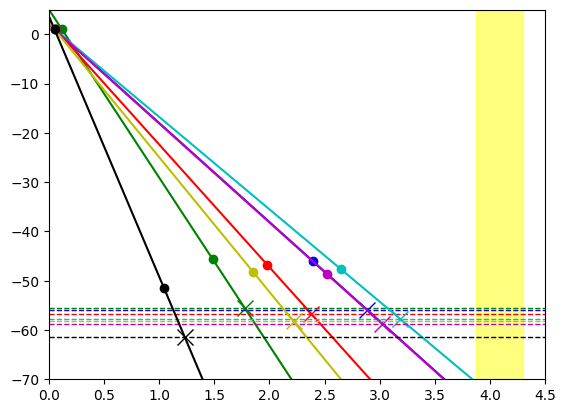

In [82]:
# Loesung Aufgabe 2c
bandidx = 6
impuls_mx =[]
impuls_mx_id=[]
for sig in sqir.time:
    impuls_mx_id.append(np.argmax(sig[0]) /fs)
    impuls_mx.append(np.max(sig[0]))

# (Lundeby et al. 1995) 'The last 10% of time of the impulse reasponse should be treated as noise
length = fs * 4.3 * 0.1
end = fs* 4.3
start = fs *4.3 - length
nf_sqir = pf.dsp.time_window(sqir,[start,end],window="boxcar",crop="window")
nfl = pf.dsp.rms(nf_sqir)
nf = 10*np.log10(nfl) #convert to db
print(nf)
B = []
t_1 = []
for c, bandidx in zip(['g','r','b','c','m','y','k'],range(7)):
    sqirdb = 10*np.log10(sqir.time[bandidx][0])
    sqirdb = sqirdb[np.argmax(sqirdb):]
    sqirdb -= nf[bandidx] + 10
    sqirdb = np.power(sqirdb,2)
    intersectx , intersecty = np.argmin(sqirdb)/fs, np.min(sqirdb) + nf[bandidx] +10

    m = (intersecty - impuls_mx[bandidx]) / (intersectx - impuls_mx_id[bandidx])
    b = impuls_mx[bandidx] - impuls_mx_id[bandidx]*m 
    B.append(m[0])
    x = (nf[bandidx] -b)/m
    t_1.append(x[0])
    plt.plot(impuls_mx_id[bandidx] , impuls_mx[bandidx], color=c, marker='o')
    plt.plot([0,4.5],[b, m*4.5 +b], color=c)
    plt.plot(x, nf[bandidx], color=c , marker='x' , markersize=12)
    plt.plot(intersectx, intersecty, color=c, marker='o')

    plt.plot([0,4.5],[nf[bandidx],nf[bandidx]], '--',color=c, linewidth=1)
plt.ylim(-70,5)
plt.xlim(0,4.5)
plt.fill_betweenx([-130,5], start/fs, end/fs,
                color='yellow', alpha=0.5)

d. Berechnen Sie für jede dieser Kurven eine Kompensationsenergie Ecomp für den durch den Noise Floor verdeckten Teil des Ausklangs nach Lundeby et al. (1995, S. 347f.) 

(3 Punkte)

In [83]:
# Loesung Aufgabe 2d
temp = np.transpose(nf)[0]/B

A = np.log(temp)/t_1
E_comp = - (B/A)*np.power(np.e,A*t_1)
print(E_comp)


[202.12429148 163.98037681 157.8328147  163.29050584 165.56791625
 170.71774565 503.00377296]


e. Berechnen Sie unter Verwendung des oben ermittelten Anfangs- und Endpunkts der Impulsantwort und der Kompensationsenergie Ecomp die Decay Curve als Rückwärtsintegration der quadrierten Impulsantwort (Schroeder-Integral). Plotten Sie diese für die sieben Oktavbänder. 

(2 Punkte)

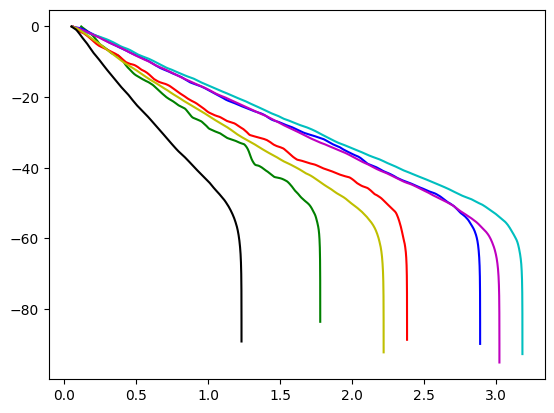

In [90]:
# Loesung Aufgabe 2e
Eimp = []
er =[]
t = np.arange(fs*4.5)/fs
for c, bandidx in zip(['g','r','b','c','m','y','k'],range(7)): 
    s = sqir.time[bandidx][0][int(impuls_mx_id[bandidx]*fs): int(t_1[bandidx]*fs)]
    Eraw = np.cumsum(s[::-1])[::-1]
    E = Eraw + 10**(-E_comp[bandidx]/10)
    Eimp.append(10*np.log10(E/E[0]))
    er.append(Eraw)
  
    plt.plot(t[int(impuls_mx_id[bandidx]*fs): int(t_1[bandidx]*fs)],Eimp[bandidx],color= c)

f. Bestimmen Sie in Oktavbändern die Nachhallzeiten T10, T20 und T30 aus den Decay Curves als Steigung einer linearen Regressionsgeraden zwischen den in ISO 3382:2008 definierten Anfangs- und Endpunkten. 

Prüfen Sie jeweils, ob die für die Bestimmung von T10, T20 und T30 erforderlichen Signal-Rauschabstände nach ISO 3382:2008  gegeben sind und geben nur die Werte aus, bei denen dies der Fall ist. 

(3 Punkte)

In [89]:
# Loesung Aufgabe 2f
Tf= []
for okt, bandidx in zip(fc, range(7)):
    Tt =[]
    print("Band "+ str(okt))
    for bnd,snrb,name in zip([-35,-25,-15],[-45,-35,-25],["T_30","T_20","T_10"]):
        seg = (Eimp[bandidx] <= -5) & (Eimp[bandidx] >= bnd )
        ts =t[int(impuls_mx_id[bandidx]*fs): int(t_1[bandidx]*fs)]
        m ,b = np.polyfit(ts[seg],Eimp[bandidx][seg],1)
        if nf[bandidx]<= snrb:
            Tt.append(-60/  m)
            print(name + ": " + str(-60/  m))
    Tf.append(Tt)
    
    print("")


Band 125
T_30: 2.0514783751689984
T_20: 1.8902532546163804
T_10: 1.6914435002752541

Band 250
T_30: 2.5637135595172027
T_20: 2.425635116070281
T_10: 2.4947778426779834

Band 500
T_30: 3.247845080107847
T_20: 3.088511524778513
T_10: 3.014154084340188

Band 1000
T_30: 3.361831113215349
T_20: 3.3396100702735776
T_10: 3.240686806743155

Band 2000
T_30: 3.131728829118352
T_20: 3.140032267390086
T_10: 3.0417808473507275

Band 4000
T_30: 2.3181469024808354
T_20: 2.2642971717735336
T_10: 2.106912503693396

Band 8000
T_30: 1.2697662572727677
T_20: 1.2277954194780196
T_10: 1.1597315810461097



g. Bestimmen Sie, unter Berücksichtigung der in c. bestimmten Anfangs- und Endpunkte sowie der in d. bestimmten Kompensationsenergie, die Werte für das Klarheitsmaß $C_{80}$ in Oktavbändern, sowie als Einzahlwert für die in DIN EN 3382-1:2008 vorgesehenen Oktavbänder. 

(2 Punkte)

In [ ]:
# Loesung Aufgabe 2g 
for okt, bandidx in zip(fc, range(7)):
    idc = 0.08 *fs
    

h. Vergleichen Sie Ihre Berechnungen mit den in 

Weinzierl, S., Sanvito, P., Schultz, F., & Büttner, C. (2015). The acoustics of renaissance theatres in Italy. Acta Acustica United with Acustica, 101(3), 632-641.

veröffentlichten Werten (Nachhallzeit und Klarheitsmaß) und nennen/diskutieren Sie drei Gründe für eine nicht perfekte Übereinstimmung. 

(2 Punkte)

*Lösung Aufgabe 2h hier*


i. Verwenden Sie die im Oktavband mit der Mittenfrequenz **1000 Hz** in Aufgabe f. bestimmte Nachhallzeit **T20** und berechnen daraus den Wert für $C_{80}$, der sich unter der Annahme eines **perfekt exponentiellen Abfalls** ergäbe (statistische Raumakustik). 

Vergleichen Sie diesen Wert mit dem empirisch bestimmten Wert in Aufgabe g. 

(2 Punkte) 

In [ ]:
# Lösung Aufgabe 2i
